In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from fredapi import Fred

In [11]:
# Paste your API key here
fred = Fred(api_key='7167653a5bb571e358c87d7a5d466bf8')

In [12]:
# S&P 500, Fed Funds Rate, CPI, Unemployment — monthly, 2000 to present
sp500       = fred.get_series('SP500',   observation_start='2000-01-01')
fed_funds   = fred.get_series('FEDFUNDS', observation_start='2000-01-01')
cpi         = fred.get_series('CPIAUCSL', observation_start='2000-01-01')
unemployment= fred.get_series('UNRATE',   observation_start='2000-01-01')

# Combine into one table and align by month
df = pd.DataFrame({
    'SP500': sp500,
    'FedFunds': fed_funds,
    'CPI': cpi,
    'Unemployment': unemployment
}).resample('MS').last().dropna()

print(df.tail())  # Quick sanity check — should show recent data

              SP500  FedFunds      CPI  Unemployment
2025-09-01  6688.46      4.22  324.245           4.4
2025-11-01  6849.09      3.88  325.063           4.5
2025-12-01  6845.50      3.72  326.031           4.4
2026-01-01  6939.03      3.64  326.588           4.3
2026-02-01  6878.88      3.64  327.460           4.4


In [13]:
# Percent change month-over-month (this is what we'll explain with macro vars)
df['SP500_Return'] = df['SP500'].pct_change() * 100
df = df.dropna()
print(df.tail())

              SP500  FedFunds      CPI  Unemployment  SP500_Return
2025-09-01  6688.46      4.22  324.245           4.4      3.532366
2025-11-01  6849.09      3.88  325.063           4.5      2.401599
2025-12-01  6845.50      3.72  326.031           4.4     -0.052416
2026-01-01  6939.03      3.64  326.588           4.3      1.366299
2026-02-01  6878.88      3.64  327.460           4.4     -0.866836


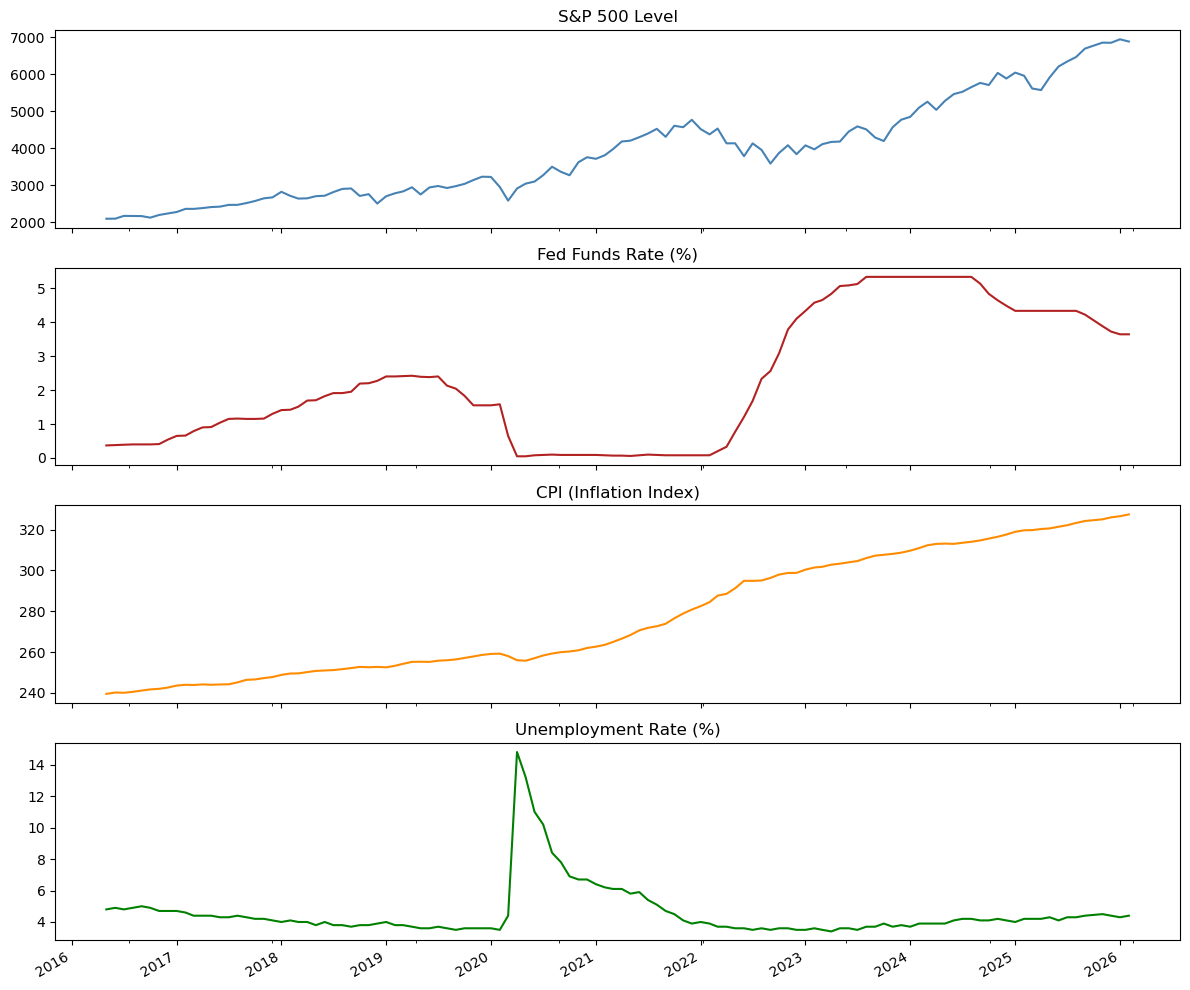

In [14]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

df['SP500'].plot(ax=axes[0], color='steelblue', title='S&P 500 Level')
df['FedFunds'].plot(ax=axes[1], color='firebrick', title='Fed Funds Rate (%)')
df['CPI'].plot(ax=axes[2], color='darkorange', title='CPI (Inflation Index)')
df['Unemployment'].plot(ax=axes[3], color='green', title='Unemployment Rate (%)')

plt.tight_layout()
plt.savefig('macro_timeseries.png', dpi=150)
plt.show()

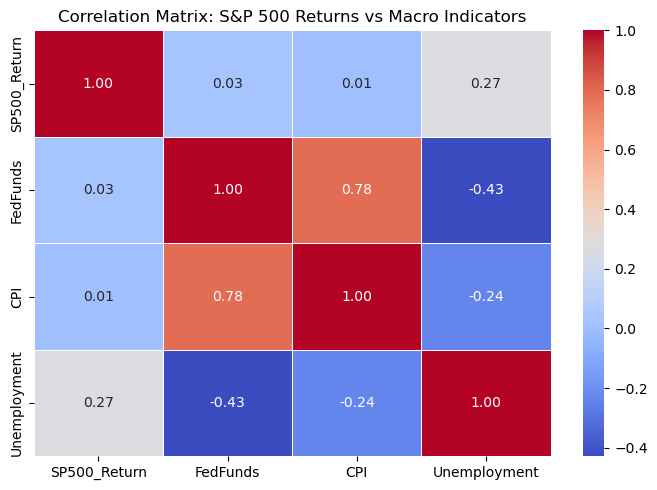

In [15]:
corr = df[['SP500_Return', 'FedFunds', 'CPI', 'Unemployment']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: S&P 500 Returns vs Macro Indicators')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [17]:
# Does the Fed rate, inflation, and unemployment explain S&P returns?
X = df[['FedFunds', 'CPI', 'Unemployment']]
X = sm.add_constant(X)  # Adds intercept
y = df['SP500_Return']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           SP500_Return   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     4.507
Date:                Tue, 07 Apr 2026   Prob (F-statistic):            0.00502
Time:                        00:26:01   Log-Likelihood:                -330.87
No. Observations:                 117   AIC:                             669.7
Df Residuals:                     113   BIC:                             680.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.3429      5.426      0.247   